In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV, LinearRegression
# from ngboost import NGBRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import lasso_path

from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis



In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [7]:
# Load the wb controls
wb_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_indicators.csv"))
wb_df.head()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,iso_alpha_3
0,2022,731821393.0,NaN,NaN,29.737205,1.040350e+12,3.196559e+11,2.535995e+11,1.016612e+11,2.360208e+11,NaN
1,2021,713090928.0,4.939318,NaN,29.955194,1.004646e+12,2.769094e+11,2.468588e+11,9.989399e+10,2.143081e+11,NaN
2,2020,694446100.0,4.585792,66.123449,30.174252,9.606813e+11,2.448648e+11,2.363776e+11,9.446765e+10,1.958722e+11,NaN
3,2019,675950189.0,5.173796,63.387090,30.391626,9.890095e+11,2.770649e+11,2.482358e+11,1.014837e+11,2.217922e+11,NaN
4,2018,657801085.0,3.945917,62.242631,30.611512,9.677734e+11,2.838657e+11,2.437429e+11,1.002104e+11,2.275611e+11,NaN


In [8]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   year                                6118 non-null   int64  
 1   pop_total                           6095 non-null   float64
 2   electricity_from_renewables_pct     5617 non-null   float64
 3   renewable_energy_consumption_pct    5710 non-null   float64
 4   forest_area_pct                     5953 non-null   float64
 5   gdp_2015_usd                        5832 non-null   float64
 6   imports_2015_usd                    4449 non-null   float64
 7   industry_value_added_2015_usd       5254 non-null   float64
 8   manufacturing_value_added_2015_usd  4733 non-null   float64
 9   exports_2015_usd                    4413 non-null   float64
 10  iso_alpha_3                         4945 non-null   object 
dtypes: float64(9), int64(1), object(1)
memory u

In [9]:
indicators_and_emissions_df = pd.merge(emissions_df, wb_df, on=["iso_alpha_3", "year"], how="left")
indicators_and_emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd
0,ABW,High income,Latin America & Caribbean,2000,0.335765,90588.0,0.0,0.2,2.333333,2.735727e+09,NaN,NaN,NaN,NaN
1,ABW,High income,Latin America & Caribbean,2001,0.344135,91439.0,0.0,0.2,2.333333,2.850135e+09,NaN,NaN,NaN,NaN
2,ABW,High income,Latin America & Caribbean,2002,0.363222,92074.0,0.0,0.2,2.333333,2.823203e+09,NaN,NaN,NaN,NaN
3,ABW,High income,Latin America & Caribbean,2003,0.412246,93128.0,0.0,0.2,2.333333,2.854554e+09,NaN,NaN,NaN,NaN
4,ABW,High income,Latin America & Caribbean,2004,0.430187,95138.0,0.0,0.2,2.333333,3.062758e+09,NaN,NaN,NaN,NaN


In [10]:
## remove unnecessary columns
indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=[
                                                        "income_group",
                                                        "region"
                    ])

# move total_emissions to the end
indicators_and_emissions_df = indicators_and_emissions_df[[col for col in indicators_and_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
indicators_and_emissions_df.head()

,iso_alpha_3,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
0,ABW,2000,90588.0,0.0,0.2,2.333333,2.735727e+09,NaN,NaN,NaN,NaN,0.335765
1,ABW,2001,91439.0,0.0,0.2,2.333333,2.850135e+09,NaN,NaN,NaN,NaN,0.344135
2,ABW,2002,92074.0,0.0,0.2,2.333333,2.823203e+09,NaN,NaN,NaN,NaN,0.363222
3,ABW,2003,93128.0,0.0,0.2,2.333333,2.854554e+09,NaN,NaN,NaN,NaN,0.412246
4,ABW,2004,95138.0,0.0,0.2,2.333333,3.062758e+09,NaN,NaN,NaN,NaN,0.430187


In [11]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         4485 non-null   object 
 1   year                                4485 non-null   int64  
 2   pop_total                           4462 non-null   float64
 3   electricity_from_renewables_pct     4216 non-null   float64
 4   renewable_energy_consumption_pct    4324 non-null   float64
 5   forest_area_pct                     4402 non-null   float64
 6   gdp_2015_usd                        4317 non-null   float64
 7   imports_2015_usd                    3431 non-null   float64
 8   industry_value_added_2015_usd       4032 non-null   float64
 9   manufacturing_value_added_2015_usd  3743 non-null   float64
 10  exports_2015_usd                    3431 non-null   float64
 11  total_emissions                     4485 no

## In this version we only care about OECD countries

In [12]:
oecd_iso_alpha_3 = eda_utils.get_oecd_iso_codes()
indicators_and_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["iso_alpha_3"].isin(oecd_iso_alpha_3)]
indicators_and_emissions_df = indicators_and_emissions_df.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)
indicators_and_emissions_df.head()

,iso_alpha_3,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
0,AUS,2000,19028802.0,0.585138,8.4,17.158156,8.726517e+11,1.165496e+11,2.059139e+11,8.104095e+10,1.579306e+11,581.422036
1,AUS,2001,19274701.0,0.711866,8.4,17.128633,8.903238e+11,1.154136e+11,2.039505e+11,8.291277e+10,1.715792e+11,602.437642
2,AUS,2002,19495210.0,0.877634,8.7,17.099111,9.257550e+11,1.169708e+11,2.127592e+11,8.519807e+10,1.707368e+11,606.209253
3,AUS,2003,19720737.0,1.062083,7.2,17.069589,9.543678e+11,1.324079e+11,2.253395e+11,8.875237e+10,1.715975e+11,607.749769
4,AUS,2004,19932722.0,1.126409,6.7,17.040066,9.946831e+11,1.502817e+11,2.303904e+11,9.002694e+10,1.738784e+11,608.183791


In [13]:
# Check if we are missing any oecd countries
eda_utils.find_missing_oecd_countries(indicators_and_emissions_df.iso_alpha_3.unique())

set()

In [14]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851 entries, 0 to 850
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         851 non-null    object 
 1   year                                851 non-null    int64  
 2   pop_total                           851 non-null    float64
 3   electricity_from_renewables_pct     814 non-null    float64
 4   renewable_energy_consumption_pct    814 non-null    float64
 5   forest_area_pct                     850 non-null    float64
 6   gdp_2015_usd                        851 non-null    float64
 7   imports_2015_usd                    851 non-null    float64
 8   industry_value_added_2015_usd       829 non-null    float64
 9   manufacturing_value_added_2015_usd  829 non-null    float64
 10  exports_2015_usd                    851 non-null    float64
 11  total_emissions                     851 non-n

## Data Cleaning

In [15]:
# Fill missing values for numeric columns
indicators_and_emissions_df = dcu.fill_numeric_missing_by_group(indicators_and_emissions_df, ["iso_alpha_3"])

In [16]:
indicators_and_emissions_df.describe()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
count,851.00000,8.510000e+02,851.000000,851.000000,851.000000,8.510000e+02,8.510000e+02,8.510000e+02,8.510000e+02,8.510000e+02,851.000000
mean,2011.00000,3.491213e+07,10.439311,19.481669,35.006019,1.212298e+12,3.071302e+11,2.775024e+11,1.725056e+11,3.035282e+11,396.418943
std,6.63715,5.607785e+07,11.909584,15.979310,17.838481,2.856413e+12,4.543162e+11,5.778710e+11,3.713483e+11,3.923726e+11,938.577015
min,2000.00000,2.812050e+05,-6.259713,0.700000,0.297556,1.185973e+10,4.939037e+09,2.639563e+09,1.217982e+09,4.071601e+09,-2.667559
25%,2005.00000,5.339244e+06,1.981192,7.900000,22.726305,1.650580e+11,6.392526e+10,3.766319e+10,2.149729e+10,5.958573e+10,48.220840
50%,2011.00000,1.050333e+07,6.085865,15.200000,33.469666,3.531793e+11,1.397031e+11,8.768374e+10,5.182212e+10,1.542562e+11,85.443819
75%,2017.00000,4.742665e+07,15.814286,27.700000,40.029846,1.161148e+12,3.977691e+11,3.125168e+11,1.541383e+11,4.271018e+11,444.286318
max,2022.00000,3.332714e+08,81.557609,82.900000,73.735645,2.144339e+13,3.542496e+12,3.383977e+12,2.123243e+12,2.456083e+12,6318.595153


In [17]:
# Check which rows have negative electricity_from_renewables_pct
indicators_and_emissions_df[indicators_and_emissions_df["electricity_from_renewables_pct"] < 0]

,iso_alpha_3,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
156,COL,2018,49024465.0,-1.713818,30.4,53.664245,3.114792e+11,6.871918e+10,8.374226e+10,3.743077e+10,4.731595e+10,299.802068
155,COL,2017,48131078.0,-3.013332,32.2,53.843867,3.036916e+11,6.494864e+10,8.350081e+10,3.688660e+10,4.701396e+10,284.605612
154,COL,2016,47437512.0,-0.916667,30.5,54.041902,2.996187e+11,6.429359e+10,8.533903e+10,3.756900e+10,4.583625e+10,281.236866
153,COL,2015,46969940.0,-2.952924,31.1,54.199784,2.934924e+11,6.665374e+10,8.390785e+10,3.639568e+10,4.593218e+10,270.190933
152,COL,2014,46565429.0,-2.282319,32.1,54.321123,2.850661e+11,6.738210e+10,8.218743e+10,3.568081e+10,4.518303e+10,261.938302
151,COL,2013,46151584.0,-6.259713,32.0,54.442462,2.727931e+11,6.252978e+10,7.949429e+10,3.467855e+10,4.531397e+10,262.021733
138,COL,2000,39089934.0,-0.225986,27.9,56.543939,1.570168e+11,1.958041e+10,4.641478e+10,2.265713e+10,2.488228e+10,262.163999


In [18]:
# Drop rows with negative electricity_from_renewables_pct
indicators_and_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["electricity_from_renewables_pct"] >= 0]

In [19]:
# Check negative emissions
negative_emissions_df = indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array(['LVA'], dtype=object)

In [20]:
# Drop the negative emissions
indicators_and_emissions_df =indicators_and_emissions_df[indicators_and_emissions_df["total_emissions"] >= 0]

In [21]:
# Check for duplicates
duplicates_df = indicators_and_emissions_df[indicators_and_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, pop_total, electricity_from_renewables_pct, renewable_energy_consumption_pct, forest_area_pct, gdp_2015_usd, imports_2015_usd, industry_value_added_2015_usd, manufacturing_value_added_2015_usd, exports_2015_usd, total_emissions]
Index: []


In [22]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = indicators_and_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than x records?
x = 23
countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
print(countries_with_less_than_x_records)

Countries with less than 23 records: 2
   iso_alpha_3  count
35         LVA     20
36         COL     16


In [23]:
# Remove the countries with less than x records from the indicators_and_emissions_df
countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [24]:
# Check the max year for every country
max_year_df = indicators_and_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2022]


In [25]:
indicators_and_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_alpha_3                         805 non-null    object 
 1   year                                805 non-null    int64  
 2   pop_total                           805 non-null    float64
 3   electricity_from_renewables_pct     805 non-null    float64
 4   renewable_energy_consumption_pct    805 non-null    float64
 5   forest_area_pct                     805 non-null    float64
 6   gdp_2015_usd                        805 non-null    float64
 7   imports_2015_usd                    805 non-null    float64
 8   industry_value_added_2015_usd       805 non-null    float64
 9   manufacturing_value_added_2015_usd  805 non-null    float64
 10  exports_2015_usd                    805 non-null    float64
 11  total_emissions                     805 non-n

In [26]:
indicators_and_emissions_df.describe()

,year,pop_total,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_2015_usd,imports_2015_usd,industry_value_added_2015_usd,manufacturing_value_added_2015_usd,exports_2015_usd,total_emissions
count,805.000000,8.050000e+02,805.000000,805.000000,805.000000,8.050000e+02,8.050000e+02,8.050000e+02,8.050000e+02,8.050000e+02,805.000000
mean,2011.000000,3.555393e+07,10.805791,18.654410,33.902408,1.273806e+12,3.228177e+11,2.912344e+11,1.813485e+11,3.193816e+11,411.174985
std,6.637373,5.735823e+07,12.054856,16.003931,17.714218,2.924896e+12,4.621954e+11,5.911721e+11,3.799045e+11,3.976153e+11,962.439291
min,2000.000000,2.812050e+05,0.000000,0.700000,0.297556,1.185973e+10,4.939037e+09,2.639563e+09,1.217982e+09,4.071601e+09,8.129184
25%,2005.000000,5.378867e+06,2.212972,7.600000,22.604447,1.809566e+11,7.134845e+10,4.013721e+10,2.245184e+10,7.078914e+10,50.192429
50%,2011.000000,1.050333e+07,6.702956,14.100000,33.152085,3.746623e+11,1.619018e+11,9.540193e+10,5.569316e+10,1.715975e+11,85.443819
75%,2017.000000,4.818456e+07,16.282398,24.900000,38.716438,1.198984e+12,4.166795e+11,3.215675e+11,1.631166e+11,4.401310e+11,462.342363
max,2022.000000,3.332714e+08,81.557609,82.900000,73.735645,2.144339e+13,3.542496e+12,3.383977e+12,2.123243e+12,2.456083e+12,6318.595153


In [27]:
# indicators_and_emissions_df = indicators_and_emissions_df.drop(columns=["pop_total"])

In [28]:
indicators_and_emissions_df.iso_alpha_3.unique().shape

(35,)

## EDA 1

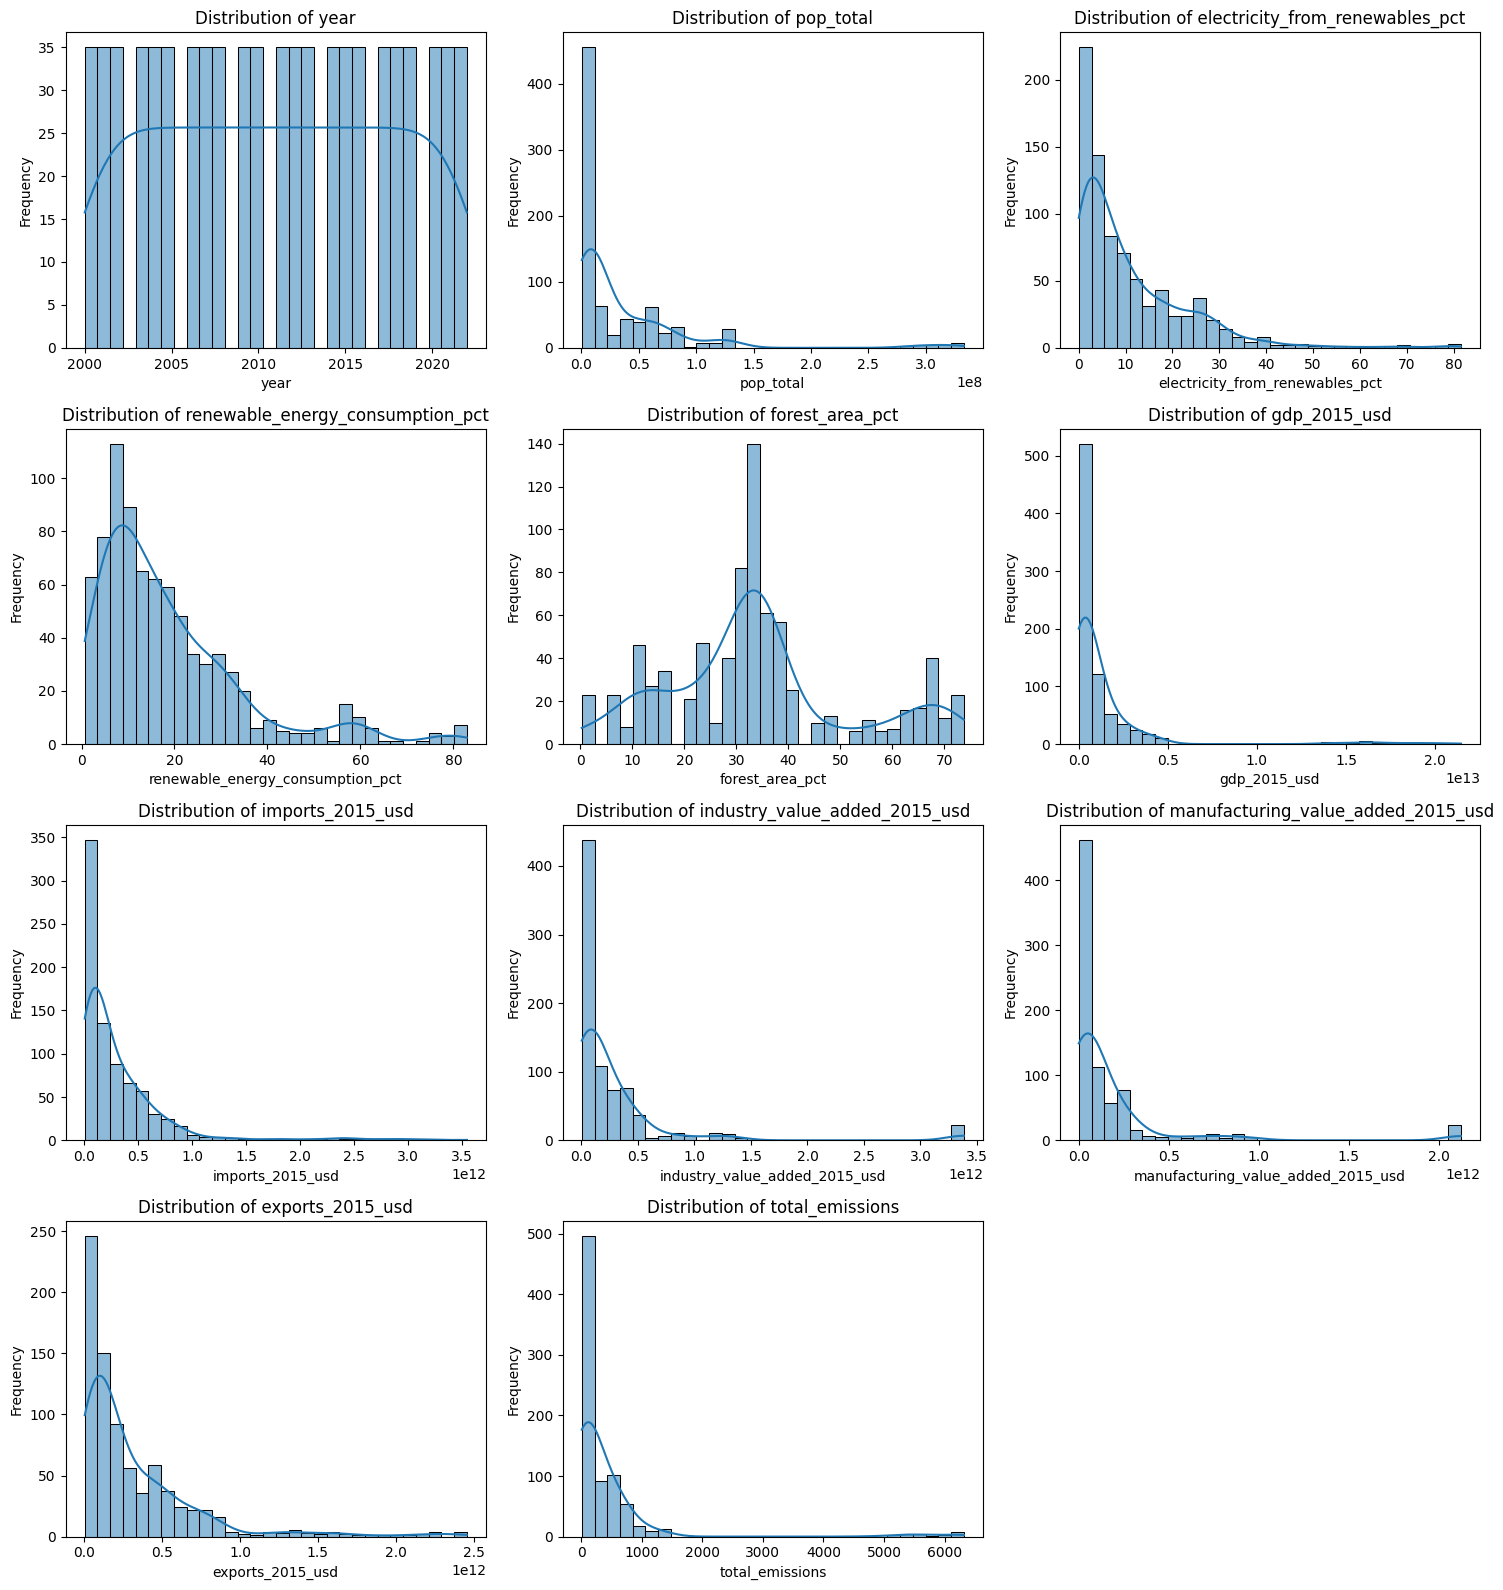

In [29]:
eda_utils.plot_numeric_fields_distributions(indicators_and_emissions_df)

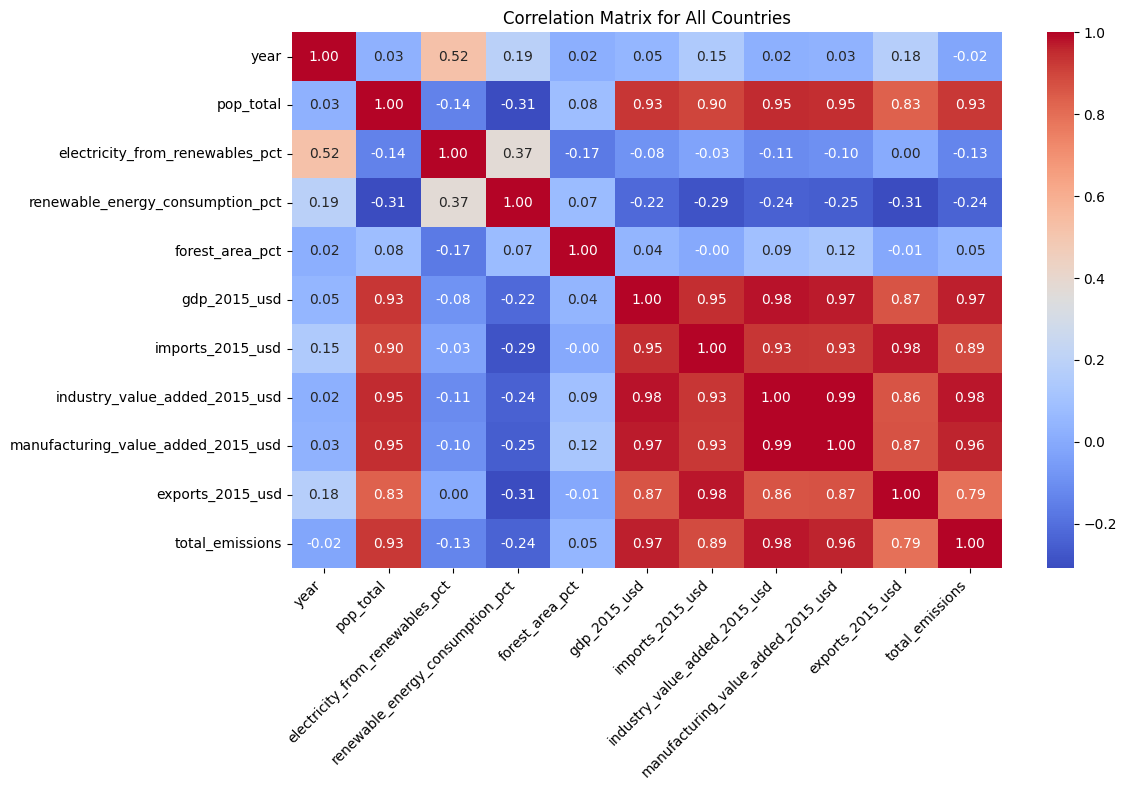

In [30]:
eda_utils.plot_correlation_matrix(indicators_and_emissions_df, figsize=(12,8))

## Feature Engineering for Numeric Features

In [31]:
# Get the numeric columns
numeric_cols = indicators_and_emissions_df.select_dtypes(include=["float64", "int64"]).columns.tolist()
numeric_cols_to_drop = ["year"]
numeric_cols = [col for col in numeric_cols if col not in numeric_cols_to_drop]
numeric_cols

['pop_total',
 'electricity_from_renewables_pct',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_2015_usd',
 'imports_2015_usd',
 'industry_value_added_2015_usd',
 'manufacturing_value_added_2015_usd',
 'exports_2015_usd',
 'total_emissions']

In [32]:
training_df = indicators_and_emissions_df.copy()

In [33]:
# Log transform the numeric columns with high skewness
training_df_log_transformed = fe.log_transform_high_skew(indicators_and_emissions_df, numeric_cols, skew_threshold=1.0)
training_df_log_transformed.head()

Columns dropped due to high skewness: ['pop_total', 'electricity_from_renewables_pct', 'renewable_energy_consumption_pct', 'gdp_2015_usd', 'imports_2015_usd', 'industry_value_added_2015_usd', 'manufacturing_value_added_2015_usd', 'exports_2015_usd', 'total_emissions']


,iso_alpha_3,year,forest_area_pct,log_pop_total,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
0,AUS,2000,17.158156,16.761464,0.460671,2.240710,27.494802,25.481583,26.050724,25.118220,25.785422,6.367195
1,AUS,2022,17.421315,17.074161,0.460671,2.240710,28.092951,26.502725,26.535734,25.169941,26.410877,6.244131
2,AUS,2021,17.421315,17.061434,3.088191,2.587764,28.051402,26.431968,26.530146,25.145813,26.414388,6.225081
3,AUS,2020,17.421315,17.060025,2.884104,2.501436,28.030510,26.463199,26.536910,25.128987,26.503297,6.246983
4,AUS,2019,17.421315,17.047691,2.684873,2.424803,28.031707,26.531130,26.539630,25.148433,26.520527,6.287117


In [34]:
training_df_log_transformed.describe()

,year,forest_area_pct,log_pop_total,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
count,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000,805.000000
mean,2011.000000,33.902408,16.399062,1.983780,2.671429,26.709296,25.774950,25.282938,24.721801,25.806633,4.868158
std,6.637373,17.714218,1.521628,1.028679,0.814316,1.539969,1.285134,1.563043,1.612177,1.281614,1.477090
min,2000.000000,0.297556,12.546843,0.000000,0.530628,23.196414,22.320436,21.693879,20.920461,22.127302,2.211476
25%,2005.000000,22.604447,15.497989,1.167196,2.151762,25.921523,24.990841,24.415570,23.834638,24.982971,3.935592
50%,2011.000000,33.152085,16.167203,2.041604,2.714695,26.649291,25.810256,25.281365,24.743123,25.868417,4.459495
75%,2017.000000,38.716438,17.690549,2.849689,3.254243,27.812495,26.755583,26.496473,25.817731,26.810338,6.138466
max,2022.000000,73.735645,19.624468,4.413496,4.429626,30.696437,28.895853,28.850073,28.383966,28.529589,8.751410


In [35]:
training_df_log_transformed.isna().sum()

iso_alpha_3                               0
year                                      0
forest_area_pct                           0
log_pop_total                             0
log_electricity_from_renewables_pct       0
log_renewable_energy_consumption_pct      0
log_gdp_2015_usd                          0
log_imports_2015_usd                      0
log_industry_value_added_2015_usd         0
log_manufacturing_value_added_2015_usd    0
log_exports_2015_usd                      0
log_total_emissions                       0
dtype: int64

In [36]:
training_df.isna().sum()

iso_alpha_3                           0
year                                  0
pop_total                             0
electricity_from_renewables_pct       0
renewable_energy_consumption_pct      0
forest_area_pct                       0
gdp_2015_usd                          0
imports_2015_usd                      0
industry_value_added_2015_usd         0
manufacturing_value_added_2015_usd    0
exports_2015_usd                      0
total_emissions                       0
dtype: int64

## EDA log transformed data

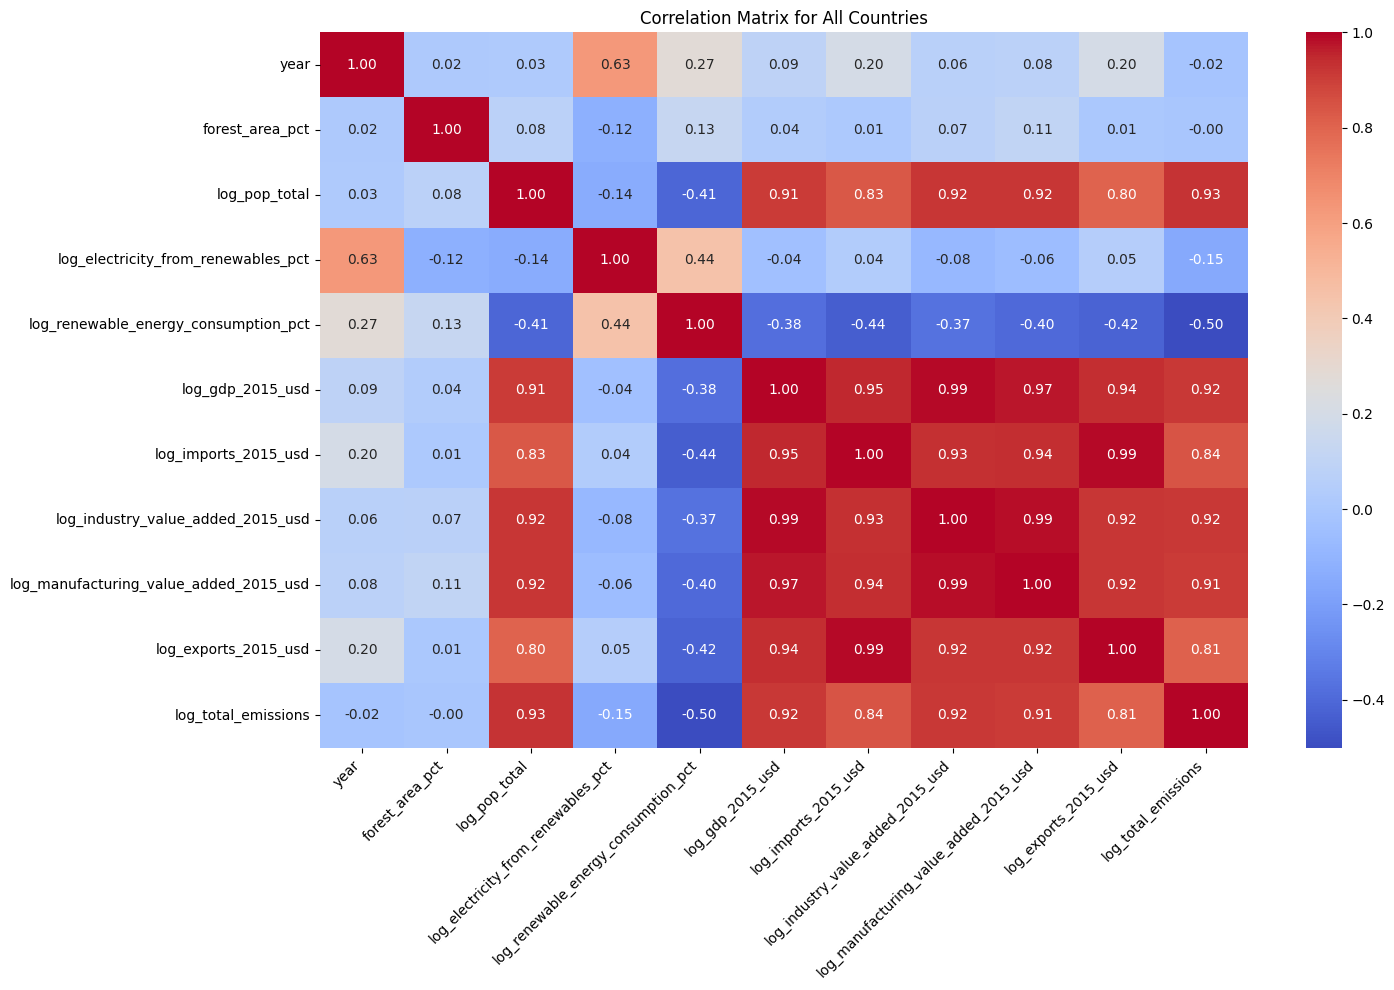

In [37]:
eda_utils.plot_correlation_matrix(training_df_log_transformed, figsize=(15,10))

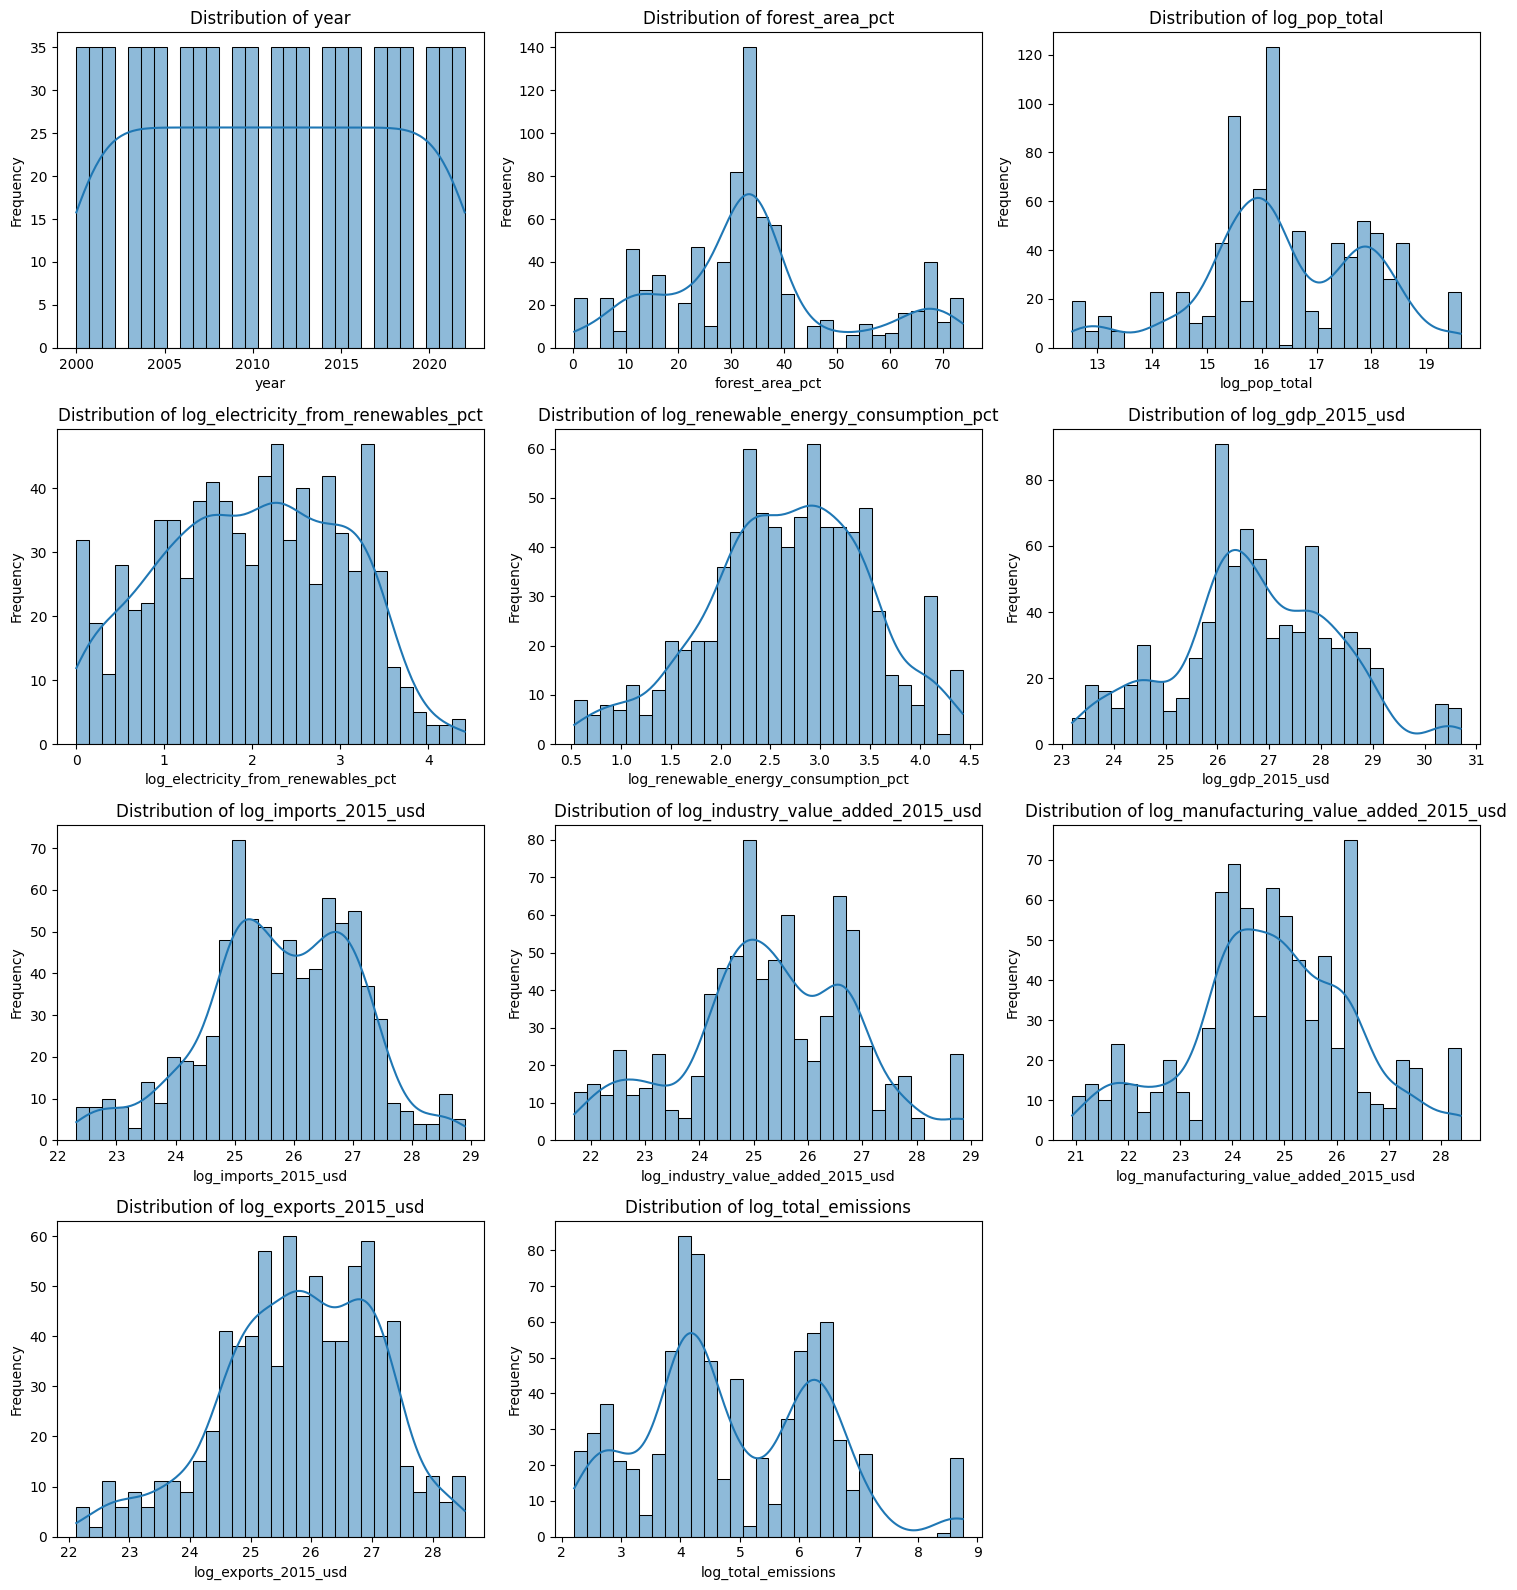

In [38]:
eda_utils.plot_numeric_fields_distributions(training_df_log_transformed)

## Create a version of the training data without multicollinear features

In [39]:
training_df_no_multicolli = dcu.remove_high_vif_features(training_df_log_transformed, target_col="log_total_emissions", exclude_cols=["year", "iso_alpha_3"], thresh=5.0, verbose=True)

Dropping 'log_imports_2015_usd' with VIF: 128.72
Dropping 'log_industry_value_added_2015_usd' with VIF: 115.24
Dropping 'log_gdp_2015_usd' with VIF: 28.86
Dropping 'log_manufacturing_value_added_2015_usd' with VIF: 19.09
All VIF values are below threshold.


In [40]:
training_df_no_multicolli.head()

,iso_alpha_3,year,log_total_emissions,forest_area_pct,log_pop_total,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_exports_2015_usd
0,AUS,2000,6.367195,17.158156,16.761464,0.460671,2.240710,25.785422
1,AUS,2022,6.244131,17.421315,17.074161,0.460671,2.240710,26.410877
2,AUS,2021,6.225081,17.421315,17.061434,3.088191,2.587764,26.414388
3,AUS,2020,6.246983,17.421315,17.060025,2.884104,2.501436,26.503297
4,AUS,2019,6.287117,17.421315,17.047691,2.684873,2.424803,26.520527


In [41]:
training_df_no_multicolli.isna().sum()

iso_alpha_3                             0
year                                    0
log_total_emissions                     0
forest_area_pct                         0
log_pop_total                           0
log_electricity_from_renewables_pct     0
log_renewable_energy_consumption_pct    0
log_exports_2015_usd                    0
dtype: int64

## ML

In [42]:
training_df_log_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   iso_alpha_3                             805 non-null    object 
 1   year                                    805 non-null    int64  
 2   forest_area_pct                         805 non-null    float64
 3   log_pop_total                           805 non-null    float64
 4   log_electricity_from_renewables_pct     805 non-null    float64
 5   log_renewable_energy_consumption_pct    805 non-null    float64
 6   log_gdp_2015_usd                        805 non-null    float64
 7   log_imports_2015_usd                    805 non-null    float64
 8   log_industry_value_added_2015_usd       805 non-null    float64
 9   log_manufacturing_value_added_2015_usd  805 non-null    float64
 10  log_exports_2015_usd                    805 non-null    float6

In [47]:
rf_tune_params = {
    # number of trees
    'rf__n_estimators': [100, 200, 500],
    # how deep each tree can grow
    'rf__max_depth': [None, 10, 20, 30],
    # minimum samples required to split an internal node
    'rf__min_samples_split': [2, 5, 10],
    # minimum samples required to be at a leaf node
    'rf__min_samples_leaf': [1, 2, 4],
    # number of features to consider at each split
    'rf__max_features': ['auto', 'sqrt', 'log2'],
    # whether samples are drawn with replacement
    'rf__bootstrap': [True, False]
}



Cross-Validation Results:
----------------------------------------------------------------------------------------------------
Model              Group MAE    (std)     Time MAE    (std)     Group R2    (std)      Time R2    (std)
----------------------------------------------------------------------------------------------------
RandomForest        227.0925 275.1719     238.3278 298.9003       0.5581   0.3399       0.5736   0.3536
ElasticNet          179.3063 107.5720     197.4722 160.0588       0.6640   0.1259       0.3720   0.9457
Median              377.0605 318.3382     405.2906 344.2358      -0.3110   0.2579      -0.2865   0.1102

Evaluation Results:
------------------------------------------------------------
Model            Train MAE   Test MAE   Train R2    Test R2
------------------------------------------------------------
RandomForest        4.0259    57.4646     0.9999     0.9782
ElasticNet        121.4568   159.3383     0.9546     0.9207
Median            372.7661   340

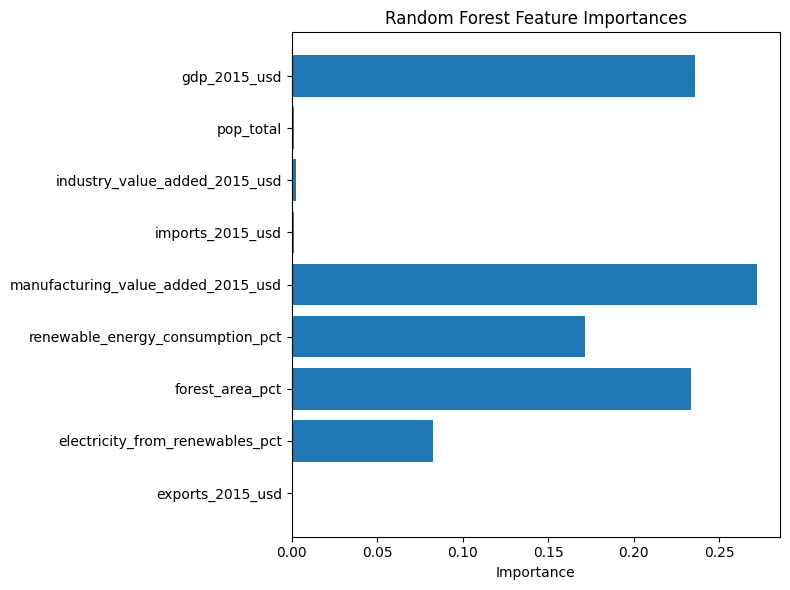

In [43]:
reg_a = RegressionAnalysis(training_df,
                           target_col="total_emissions",
                           group_col="iso_alpha_3",
                           year_col="year",
                           feature_cols=None,
                           rf_tune=False,
                           rf_tune_params=None,
                           )

reg_a.run_all(plot_importances=True)

In [55]:
log_reg_a = RegressionAnalysis(training_df_log_transformed,
                           target_col="log_total_emissions",
                           group_col="iso_alpha_3",
                           year_col="year",
                           feature_cols=None,
                           rf_tune=False,
                           rf_tune_params=rf_tune_params,
                           )


Cross-Validation Results:
----------------------------------------------------------------------------------------------------
Model              Group MAE    (std)     Time MAE    (std)     Group R2    (std)      Time R2    (std)
----------------------------------------------------------------------------------------------------
RandomForest          0.4729   0.0895       0.4119   0.0975       0.8181   0.0534       0.8428   0.0482
ElasticNet            0.4126   0.1159       0.5041   0.3431       0.8430   0.0423       0.6905   0.4634
Median                1.2669   0.2123       1.2871   0.3078      -0.2456   0.2725      -0.0089   0.0116

Evaluation Results:
------------------------------------------------------------
Model            Train MAE   Test MAE   Train R2    Test R2
------------------------------------------------------------
RandomForest        0.0177     0.1780     0.9996     0.9561
ElasticNet          0.2929     0.3162     0.9240     0.9179
Median              1.2239     1

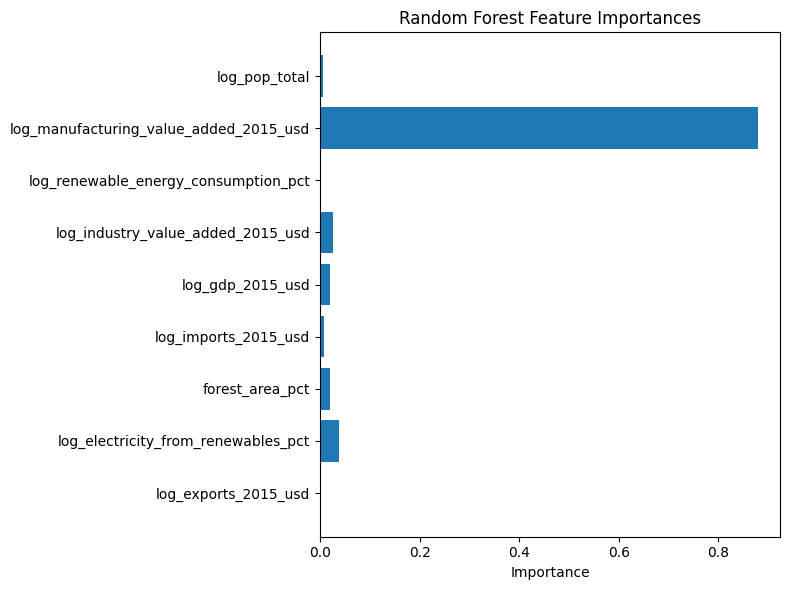

In [56]:
log_reg_a.run_all(plot_importances=True)


Cross-Validation Results:
----------------------------------------------------------------------------------------------------
Model              Group MAE    (std)     Time MAE    (std)     Group R2    (std)      Time R2    (std)
----------------------------------------------------------------------------------------------------
RandomForest          0.4746   0.1185       0.4307   0.1215       0.8105   0.0571       0.8461   0.0566
ElasticNet            0.4100   0.1387       0.4595   0.2035       0.8420   0.0671       0.8254   0.1711
Median                1.2669   0.2123       1.2871   0.3078      -0.2456   0.2725      -0.0089   0.0116

Evaluation Results:
------------------------------------------------------------
Model            Train MAE   Test MAE   Train R2    Test R2
------------------------------------------------------------
RandomForest        0.0187     0.1807     0.9995     0.9491
ElasticNet          0.3695     0.4224     0.8765     0.8733
Median              1.2239     1

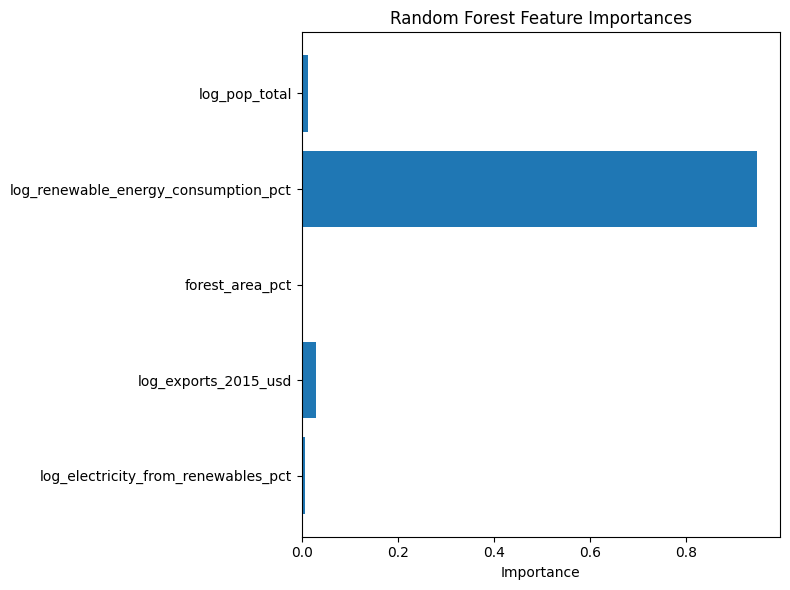

In [46]:
no_multicol_reg_a = RegressionAnalysis(training_df_no_multicolli,
                           target_col="log_total_emissions",
                           group_col="iso_alpha_3",
                           year_col="year",
                           feature_cols=None,
                           rf_tune=False,
                           rf_tune_params=None,
                           )

no_multicol_reg_a.run_all(plot_importances=True)

## Create projections

In [57]:
from utils.ml_utils import EnsembleProjections
ep = EnsembleProjections()

In [58]:
training_df_log_transformed

,iso_alpha_3,year,forest_area_pct,log_pop_total,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
0,AUS,2000,17.158156,16.761464,0.460671,2.240710,27.494802,25.481583,26.050724,25.118220,25.785422,6.367195
1,AUS,2022,17.421315,17.074161,0.460671,2.240710,28.092951,26.502725,26.535734,25.169941,26.410877,6.244131
2,AUS,2021,17.421315,17.061434,3.088191,2.587764,28.051402,26.431968,26.530146,25.145813,26.414388,6.225081
3,AUS,2020,17.421315,17.060025,2.884104,2.501436,28.030510,26.463199,26.536910,25.128987,26.503297,6.246983
4,AUS,2019,17.421315,17.047691,2.684873,2.424803,28.031707,26.531130,26.539630,25.148433,26.520527,6.287117
...,...,...,...,...,...,...,...,...,...,...,...,...
800,USA,2001,33.186756,19.467891,1.053345,1.740466,30.259217,28.168739,28.850073,28.383966,27.847749,8.738518
801,USA,2000,33.130174,19.457993,1.066065,1.856298,30.249707,28.193661,28.850073,28.383966,27.905189,8.751410
802,USA,2021,33.866926,19.620793,2.708570,2.476538,30.671624,28.813416,28.850073,28.383966,28.451613,8.537859
803,USA,2010,33.749407,19.549910,1.624281,2.128232,30.424582,28.474622,28.850073,28.383966,28.271226,8.680793


In [59]:
non_feature_cols = ["iso_alpha_3", "year", "log_total_emissions"]
feature_cols = [col for col in training_df_log_transformed.columns if col not in non_feature_cols]
feature_cols

['forest_area_pct',
 'log_pop_total',
 'log_electricity_from_renewables_pct',
 'log_renewable_energy_consumption_pct',
 'log_gdp_2015_usd',
 'log_imports_2015_usd',
 'log_industry_value_added_2015_usd',
 'log_manufacturing_value_added_2015_usd',
 'log_exports_2015_usd']

In [80]:
ensemble_ets_df = ep.generate_ensemble_ts_lhs(
    df=training_df_log_transformed,
    feature_cols=feature_cols,
    start_year=2022,
    end_year=2030,
    n_scenarios=10,
    method="ets",            # or "arima"
    arima_order=(1,1,1),     # only used if method="arima"
    random_state=42
)

ensemble_arima_df = ep.generate_ensemble_ts_lhs(
    df=training_df_log_transformed,
    feature_cols=feature_cols,
    start_year=2022,
    end_year=2030,
    n_scenarios=10,
    method="arima",          # or "ets"
    arima_order=(1,1,1),     # only used if method="arima"
    random_state=42
)


In [81]:
ensemble_ets_df.head()

,iso_alpha_3,future_id,year,forest_area_pct,log_pop_total,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd
0,AUS,id_AUS_1,2022,17.421315,17.086131,2.801792,2.309209,28.117828,26.585328,26.562353,25.159925,26.380370
1,AUS,id_AUS_1,2023,17.421315,17.095180,3.023520,2.320084,28.135652,26.494093,26.567421,25.185971,26.380309
2,AUS,id_AUS_1,2024,17.421315,17.104668,3.112723,2.353124,28.186983,26.593729,26.566958,25.154350,26.313037
3,AUS,id_AUS_1,2025,17.421315,17.120570,3.118685,2.333354,28.203259,26.582343,26.528375,25.172786,26.300790
4,AUS,id_AUS_1,2026,17.421315,17.121617,3.184127,2.359435,28.213209,26.529326,26.585185,25.154002,26.303120


In [82]:
ensemble_ets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   iso_alpha_3                             3150 non-null   object 
 1   future_id                               3150 non-null   object 
 2   year                                    3150 non-null   int64  
 3   forest_area_pct                         3150 non-null   float64
 4   log_pop_total                           3150 non-null   float64
 5   log_electricity_from_renewables_pct     3150 non-null   float64
 6   log_renewable_energy_consumption_pct    3150 non-null   float64
 7   log_gdp_2015_usd                        3150 non-null   float64
 8   log_imports_2015_usd                    3150 non-null   float64
 9   log_industry_value_added_2015_usd       3150 non-null   float64
 10  log_manufacturing_value_added_2015_usd  3150 non-null   floa

In [83]:
training_df_log_transformed.head()

,iso_alpha_3,year,forest_area_pct,log_pop_total,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions
0,AUS,2000,17.158156,16.761464,0.460671,2.240710,27.494802,25.481583,26.050724,25.118220,25.785422,6.367195
1,AUS,2022,17.421315,17.074161,0.460671,2.240710,28.092951,26.502725,26.535734,25.169941,26.410877,6.244131
2,AUS,2021,17.421315,17.061434,3.088191,2.587764,28.051402,26.431968,26.530146,25.145813,26.414388,6.225081
3,AUS,2020,17.421315,17.060025,2.884104,2.501436,28.030510,26.463199,26.536910,25.128987,26.503297,6.246983
4,AUS,2019,17.421315,17.047691,2.684873,2.424803,28.031707,26.531130,26.539630,25.148433,26.520527,6.287117


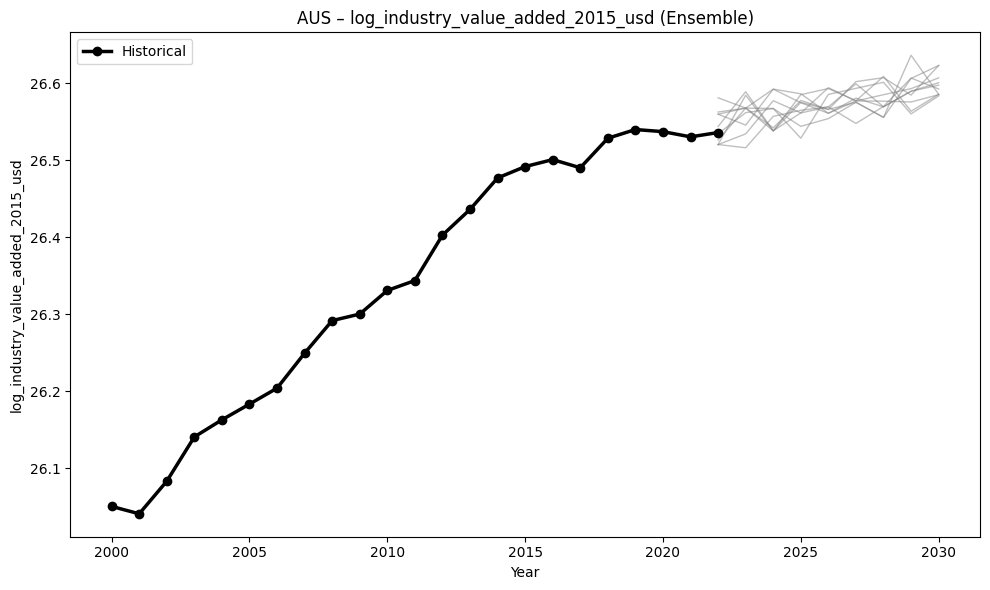

In [84]:
ep.plot_ensemble_time_series(
    df=ensemble_ets_df, 
    iso_alpha_3="AUS",
    column="log_industry_value_added_2015_usd",
    hist_df=training_df_log_transformed)

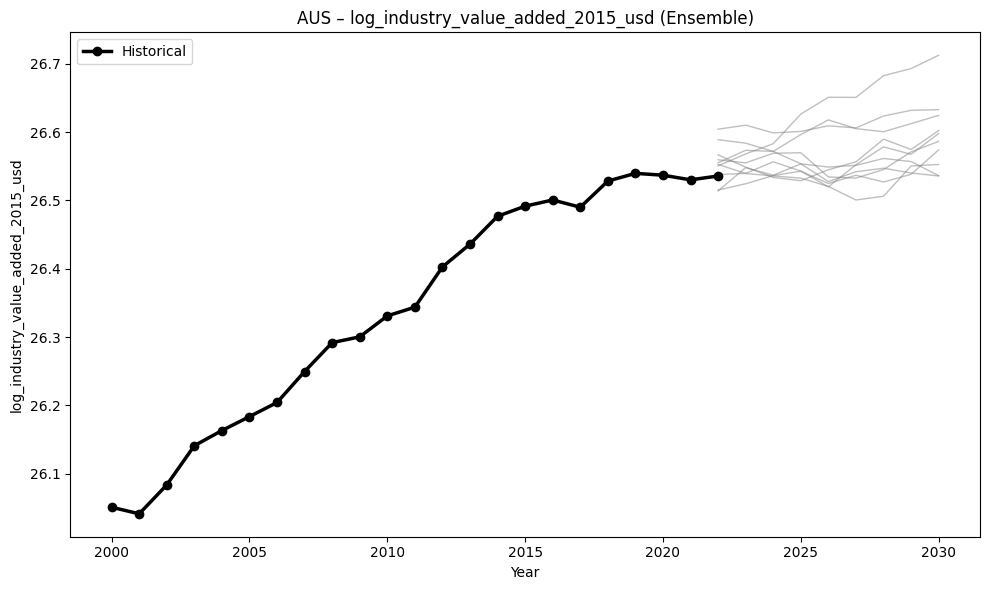

In [85]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="AUS",
    column="log_industry_value_added_2015_usd",
    hist_df=training_df_log_transformed)

In [86]:
rf_pipeline_1 = log_reg_a.pipe_rf
rf_pipeline_2 = no_multicol_reg_a.pipe_rf

In [87]:
ensemble_arima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   iso_alpha_3                             3150 non-null   object 
 1   future_id                               3150 non-null   object 
 2   year                                    3150 non-null   int64  
 3   forest_area_pct                         3150 non-null   float64
 4   log_pop_total                           3150 non-null   float64
 5   log_electricity_from_renewables_pct     3150 non-null   float64
 6   log_renewable_energy_consumption_pct    3150 non-null   float64
 7   log_gdp_2015_usd                        3150 non-null   float64
 8   log_imports_2015_usd                    3150 non-null   float64
 9   log_industry_value_added_2015_usd       3150 non-null   float64
 10  log_manufacturing_value_added_2015_usd  3150 non-null   floa

In [88]:
ensemble_arima_df_with_emissions = ep.predict_ensemble_emissions(ensemble_arima_df, rf_pipeline_1, feature_cols)
ensemble_arima_df_with_emissions.head()

,iso_alpha_3,future_id,year,forest_area_pct,log_pop_total,log_electricity_from_renewables_pct,log_renewable_energy_consumption_pct,log_gdp_2015_usd,log_imports_2015_usd,log_industry_value_added_2015_usd,log_manufacturing_value_added_2015_usd,log_exports_2015_usd,log_total_emissions,total_emissions
0,AUS,id_AUS_1,2022,17.438701,17.083914,0.701588,2.291902,28.107444,26.538652,26.550631,25.178754,26.382464,6.387036,594.093350
1,AUS,id_AUS_1,2023,17.420257,17.093211,0.537417,2.366994,28.142816,26.481935,26.568092,25.191501,26.343108,6.381744,590.957679
2,AUS,id_AUS_1,2024,17.354588,17.107952,2.677001,2.236581,28.148648,26.447547,26.583055,25.165971,26.300079,6.308783,549.375825
3,AUS,id_AUS_1,2025,17.265868,17.121114,2.400833,2.165659,28.189072,26.476162,26.626391,25.177485,26.264943,6.332927,562.801757
4,AUS,id_AUS_1,2026,17.161469,17.140141,1.699847,2.152859,28.203310,26.539686,26.651007,25.189329,26.212175,6.412805,609.601287


In [89]:
ensemble_arima_df_with_emissions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   iso_alpha_3                             3150 non-null   object 
 1   future_id                               3150 non-null   object 
 2   year                                    3150 non-null   int64  
 3   forest_area_pct                         3150 non-null   float64
 4   log_pop_total                           3150 non-null   float64
 5   log_electricity_from_renewables_pct     3150 non-null   float64
 6   log_renewable_energy_consumption_pct    3150 non-null   float64
 7   log_gdp_2015_usd                        3150 non-null   float64
 8   log_imports_2015_usd                    3150 non-null   float64
 9   log_industry_value_added_2015_usd       3150 non-null   float64
 10  log_manufacturing_value_added_2015_usd  3150 non-null   floa

In [90]:
# ensemble_ets_df_with_emissions = ep.predict_ensemble_emissions(ensemble_ets_df, rf_pipeline_2, feature_cols)
# ensemble_ets_df_with_emissions.head()

In [91]:
# ensemble_ets_df_with_emissions.info()

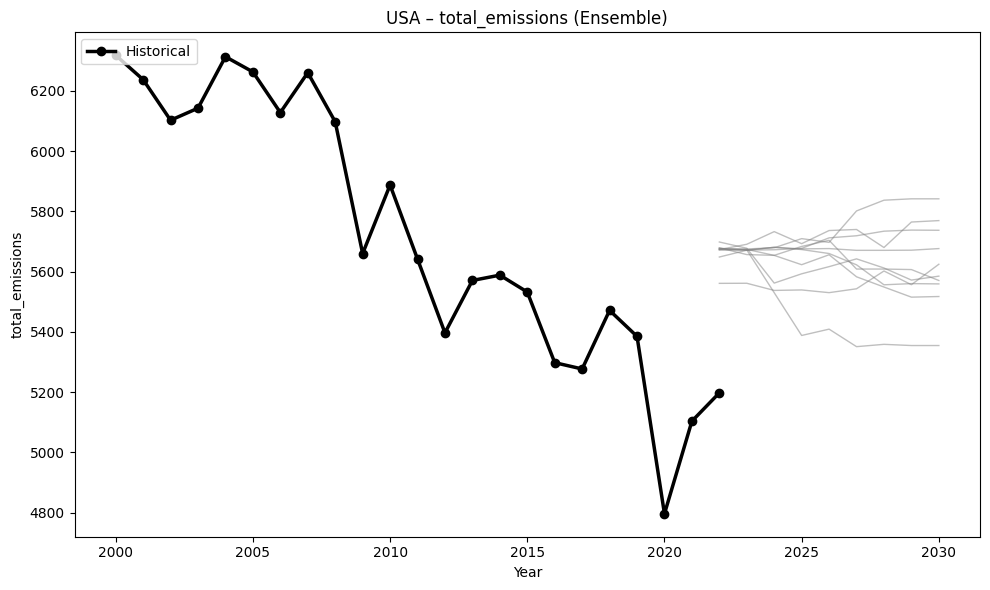

In [94]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df_with_emissions, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df)

In [93]:
# ep.plot_ensemble_time_series(
#     df=ensemble_ets_df_with_emissions, 
#     iso_alpha_3="USA",
#     column="total_emissions",
#     hist_df=training_df)